## Preprocessing & Imbalance Handling

**Goal:** Prepare the data for modeling by:
- Scaling Amount and Time features
- Splitting data into train and test sets
- Applying SMOTE to handle class imbalance

**Input:** Raw `creditcard.csv`  
**Output:** Balanced training data ready for modeling

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r'../data/creditcard.csv')
df.shape

(284807, 31)

### Feature Scaling
Amount and Time are not scaled like V1-V28.
We apply StandardScaler to bring them to the same scale.

In [6]:
scalar = StandardScaler()

df['Amount'] = scalar.fit_transform(df[['Amount']])
df['Time'] = scalar.fit_transform(df[['Time']])

print(df[['Amount', 'Time']].describe().round(4))

            Amount         Time
count  284807.0000  284807.0000
mean       -0.0000      -0.0000
std         1.0000       1.0000
min        -0.3532      -1.9966
25%        -0.3308      -0.8552
50%        -0.2653      -0.2131
75%        -0.0447       0.9372
max       102.3622       1.6421


### Train/Test Split
Splitting data into 75% training and 25% testing.
Using stratify=y to preserve the 0.173% fraud ratio in both sets.

In [8]:
X = df.drop('Class', axis=1)
Y = df['Class']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.25,
    random_state=42,
    stratify=Y
)

print(f"X_train shape : {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"\nFraud in training set : {Y_train.sum()}")
print(f"Fraud in test set : {Y_test.sum()}")
print(f"\nFraud % in train: {Y_train.sum()/len(Y_train)*100:.3f}%")
print(f"Fraud % in test : {Y_test.sum()/len(Y_test)*100:.3f}%")


X_train shape : (213605, 30)
X_test shape : (71202, 30)

Fraud in training set : 369
Fraud in test set : 123

Fraud % in train: 0.173%
Fraud % in test : 0.173%


### SMOTE - Handling Class Imbalance
Applying SMOTE only on training data to avoid data leakage.
SMOTE creates synthetic fraud samples to balance the dataset.

In [9]:
smote = SMOTE(random_state=42)

X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

print(f"Before SMOTE:")
print(f"  Genuine : {sum(Y_train==0)}")
print(f"  Fraud   : {sum(Y_train==1)}")

print(f"\nAfter SMOTE:")
print(f"  Genuine : {sum(Y_train_smote==0)}")
print(f"  Fraud   : {sum(Y_train_smote==1)}")

print(f"\nNew training size: {X_train_smote.shape}")

Before SMOTE:
  Genuine : 213236
  Fraud   : 369

After SMOTE:
  Genuine : 213236
  Fraud   : 213236

New training size: (426472, 30)


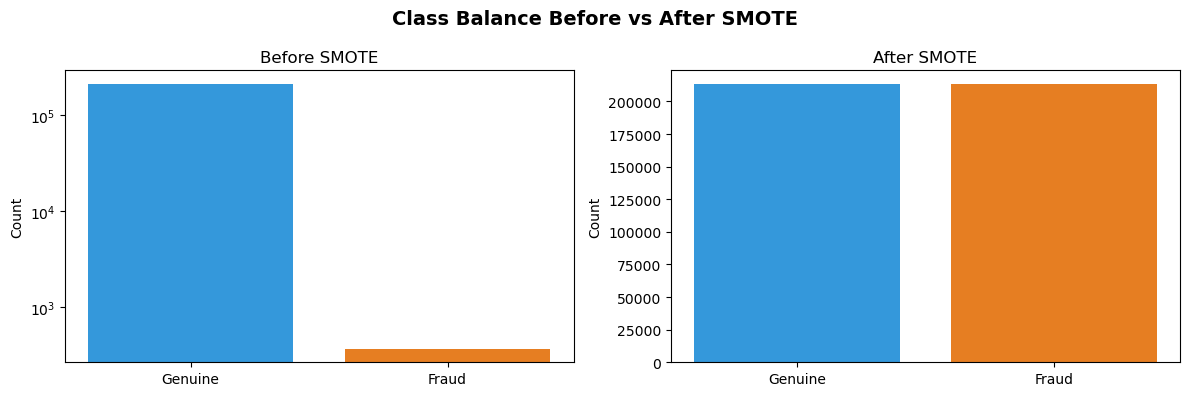

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Genuine', 'Fraud'], 
            [sum(Y_train==0), sum(Y_train==1)],
            color=['#3498db', '#e67e22'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')
axes[0].minorticks_off()

axes[1].bar(['Genuine', 'Fraud'],
            [sum(Y_train_smote==0), sum(Y_train_smote==1)],
            color=['#3498db', '#e67e22'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.suptitle('Class Balance Before vs After SMOTE', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
X_train_smote.to_csv('../data/processed/X_train.csv', index=False)
Y_train_smote.to_csv('../data/processed/Y_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
Y_test.to_csv('../data/processed/Y_test.csv', index=False)
print("Files saved successfully!")

Files saved successfully!
